<a href="https://colab.research.google.com/github/furkandr01/python_data_science/blob/main/cnn_goruntu_siniflandirma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, ReLU
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [39]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(-1,28,28,1) / 255.0
X_test = X_test.reshape(-1,28,28,1) / 255.0

In [40]:
cnn_model = Sequential([
 Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
 MaxPooling2D((2, 2)),
 Conv2D(64, (3, 3)),
 ReLU(),
 MaxPooling2D((2, 2)),
 Conv2D(128, (3, 3)),
 ReLU(),
 MaxPooling2D((2, 2)),
 Flatten(),
 Dense(128, activation="relu"),
 Dense(64, activation="relu"),
 Dense(32, activation="relu"),
 Dense(10, activation="softmax"),
])

cnn_model.compile(optimizer="adam",
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])

cnn_model.fit(X_train, y_train, epochs=10, batch_size=64,
 validation_data=(X_test, y_test))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 63ms/step - accuracy: 0.7582 - loss: 0.6545 - val_accuracy: 0.8246 - val_loss: 0.4842
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 66ms/step - accuracy: 0.8448 - loss: 0.4247 - val_accuracy: 0.8448 - val_loss: 0.4212
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.8687 - loss: 0.3566 - val_accuracy: 0.8605 - val_loss: 0.3904
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.8838 - loss: 0.3163 - val_accuracy: 0.8711 - val_loss: 0.3426
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.8950 - loss: 0.2859 - val_accuracy: 0.8801 - val_loss: 0.3270
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 57s 61ms/step - accuracy: 0.9035 - loss: 0.2628 - val_accuracy: 0.8884 - val_loss: 0.3123
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.9101 - loss: 0.2420 - val_accuracy: 0.8928 - val_loss: 0.3007
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9170 - loss: 0.2239 - 

In [41]:
def tahmin(image_path):
  img= Image.open(image_path).convert('L')
  img= img.resize((28,28))
  img_array= np.array(img)

  img_array = img_array.reshape(-1,28,28,1)/255

  img_array = 1 - img_array

  prediction = cnn_model.predict(img_array)

  predicted_number = np.argmax(prediction, axis=1)[0]

  print(predicted_number)

  plt.imshow(img, cmap="gray")
  plt.title(f"Tahmin :{predicted_number}")
  plt.axis('off')
  plt.show()

In [42]:
predictions = cnn_model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [43]:
cm = confusion_matrix(y_test, y_pred)

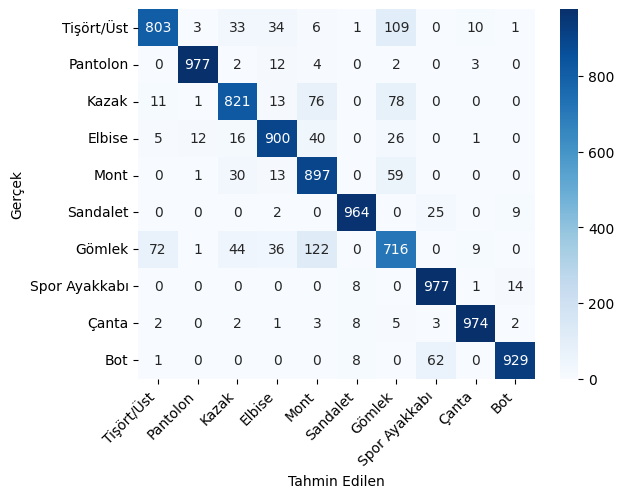

In [44]:
class_names = ["Tişört/Üst", "Pantolon", "Kazak", "Elbise", "Mont",
               "Sandalet", "Gömlek", "Spor Ayakkabı", "Çanta", "Bot"]

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [45]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test dogrulugu: {test_accuracy: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8958 - loss: 0.3074
Test dogrulugu:  0.8958


Saving test.jpg to test (1).jpg
dict_keys(['test (1).jpg'])
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
0


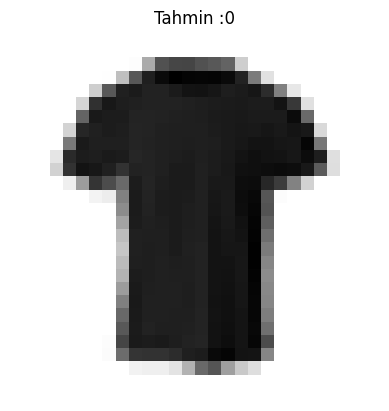

In [47]:
uploaded = files.upload()
print(uploaded.keys())
tahmin("test.jpg")